<a href="https://colab.research.google.com/github/juanjo9926/INTELIGENCIA-ARTIFICIAL-1/blob/main/Tareaclase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Importar librerías necesarias
import pandas as pd

# Ruta del archivo en Drive
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/IA_26/DATASET/wine_data.csv"

# Cargar el dataset
datos = pd.read_csv(ruta_archivo)

# Mostrar las primeras filas para verificar
datos.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


¿De que trata el dataset?

El conjunto de datos es sobre la calidad del vino, y contiene información química de diferentes vinos.

In [5]:
# Eliminar la columna "quality" porque es la variable objetivo
# (KMeans es aprendizaje no supervisado)
datos_caracteristicas = datos.drop("quality", axis=1)

# Eliminar valores nulos si existen
datos_caracteristicas = datos_caracteristicas.dropna()

# Mostrar dimensiones del dataset
print("Filas y columnas:", datos_caracteristicas.shape)

Filas y columnas: (21000, 11)


# **NORMALIZAR**
Explicación:
Se normalizan los datos para que todas las variables tengan la misma escala y el algoritmo funcione mejor.

In [6]:
# Importar herramienta para normalizar
from sklearn.preprocessing import StandardScaler

# Crear el objeto de normalización
escalador = StandardScaler()

# Aplicar normalización
datos_normalizados = escalador.fit_transform(datos_caracteristicas)

# Reducir a 3 dimensiones (PCA)
Explicación:
Se reduce el número de variables a 3 para poder graficar en 3D manteniendo la mayor información posible.

In [7]:
# Importar PCA
from sklearn.decomposition import PCA

# Reducir a 3 componentes principales
pca = PCA(n_components=3)

datos_pca = pca.fit_transform(datos_normalizados)

In [8]:
# Importar KMeans
from sklearn.cluster import KMeans

# Valores de k solicitados
valores_k = [3, 5, 7, 9]

# Aplicar KMeans para cada k
resultados = {}

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42)
    etiquetas = modelo.fit_predict(datos_normalizados)

    resultados[k] = etiquetas

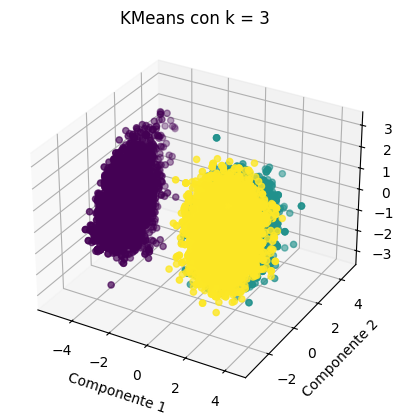

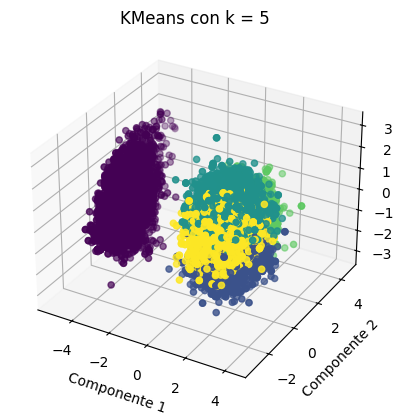

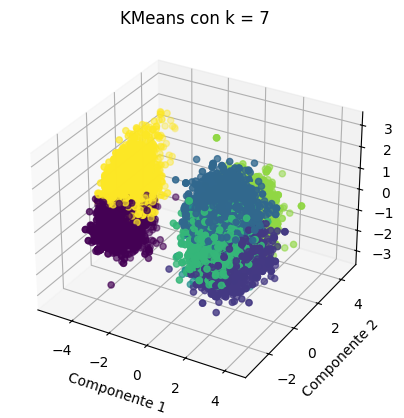

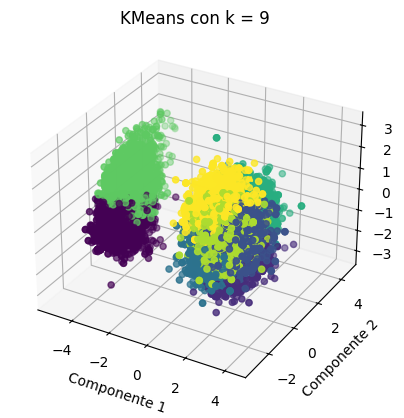

In [9]:
# Importar librerías para gráficos
import matplotlib.pyplot as plt

# Graficar para cada k
for k in valores_k:
    etiquetas = resultados[k]

    figura = plt.figure()
    eje = figura.add_subplot(111, projection='3d')

    eje.scatter(datos_pca[:, 0], datos_pca[:, 1], datos_pca[:, 2], c=etiquetas)

    eje.set_title(f"KMeans con k = {k}")
    eje.set_xlabel("Componente 1")
    eje.set_ylabel("Componente 2")
    eje.set_zlabel("Componente 3")

    plt.show()

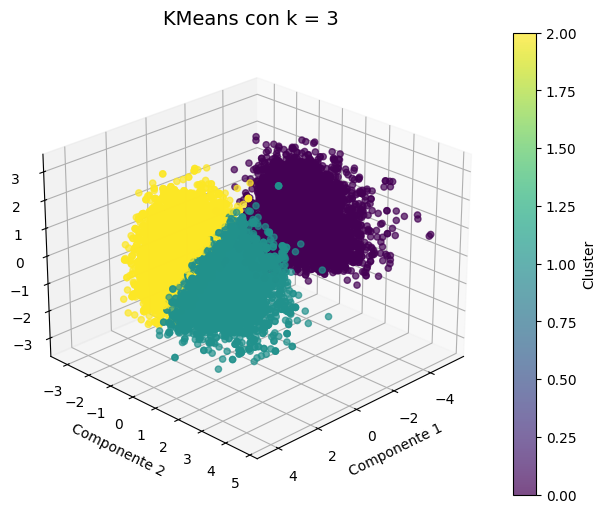

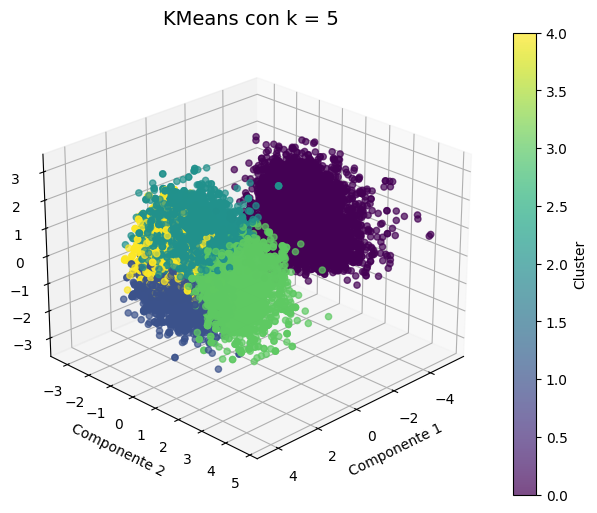

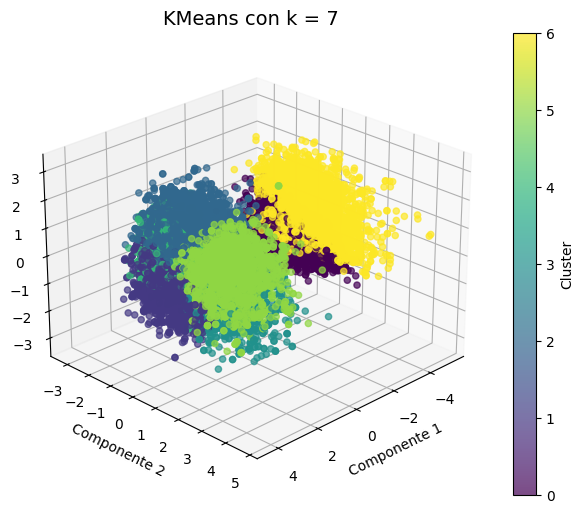

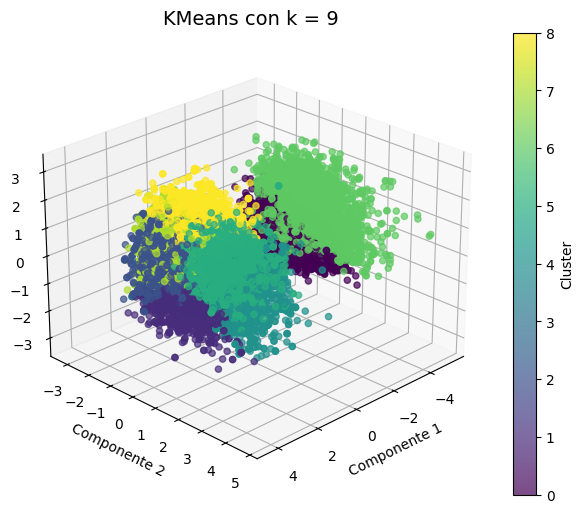

In [10]:
# Importar librerías
import matplotlib.pyplot as plt

# Graficar para cada k
for k in valores_k:
    etiquetas = resultados[k]

    figura = plt.figure(figsize=(8,6))
    eje = figura.add_subplot(111, projection='3d')

    # Gráfico con mejor visualización
    grafico = eje.scatter(
        datos_pca[:, 0],
        datos_pca[:, 1],
        datos_pca[:, 2],
        c=etiquetas,          # colores según cluster
        cmap='viridis',       # paleta de colores
        s=20,                 # tamaño de puntos
        alpha=0.7             # transparencia
    )

    # Títulos y etiquetas
    eje.set_title(f"KMeans con k = {k}", fontsize=14)
    eje.set_xlabel("Componente 1", fontsize=10)
    eje.set_ylabel("Componente 2", fontsize=10)
    eje.set_zlabel("Componente 3", fontsize=10)

    # Barra de colores (importante)
    barra = plt.colorbar(grafico, ax=eje)
    barra.set_label("Cluster")

    # Mejor ángulo de vista
    eje.view_init(elev=25, azim=45)

    plt.show()

Se considera que el valor más estratégico es k = 5, ya que ofrece un equilibrio entre la simplicidad del modelo y la capacidad de representar adecuadamente la estructura de los datos.
Valores menores como k = 3 generan agrupaciones muy generales, mientras que valores mayores como k = 7 y k = 9 producen una segmentación excesiva.